# Travel Reimbursement Approval Agent

**Assignment:** AI Developer Assignment — Travel Reimbursement Approval Agent

## README

**What this notebook does**
Evaluates the 5 sample claims in Appendix B against the policy in Appendix A using a
tool-calling agent, and outputs a structured JSON decision (`APPROVE` / `PARTIAL_APPROVE` /
`REJECT` / `MANUAL_REVIEW`) for each claim, plus a small results dashboard.

**Setup**
- Python 3.9+, `matplotlib` (bundled with most environments).
- Optional: `pip install anthropic` and set the environment variable `ANTHROPIC_API_KEY`
  to run the agent with a real LLM doing the tool-calling/reasoning.
- **No API key is required.** If `anthropic` isn't installed or no key is set, the notebook
  automatically falls back to a deterministic local agent that calls the *exact same tool
  functions* and applies the same policy Decision Guidance — so it is fully runnable
  top-to-bottom with zero manual steps and zero cost, per the assignment's free-tier/local-tools constraint.

**How to run**
Run all cells top to bottom (`Run All`). The final code cell prints the required JSON array.
The dashboard is rendered inline under `## Dashboard` and also saved as `UI SS_1.png`.

**Key design choices** (see also "Design Notes & Reasoning" near the end)
- Policy in Appendix A is encoded as structured data (`POLICY` dict) keyed by stable `POL-*`
  ids, so every decision can cite exact rule ids — this is the grounding/context step.
- Six small, single-purpose tools do the actual rule-checking (`policy_lookup`,
  `receipt_completeness_check`, `per_diem_limit_checker`, `approval_threshold_check`,
  `duplicate_detector`, `timeliness_check`), plus an `output_validator` for the final schema.
- The agent (LLM-driven when a key is present, deterministic otherwise) decides which tools
  to call, combines their outputs, and prefers `MANUAL_REVIEW` whenever information is
  missing, ambiguous, or a policy exception applies, rather than forcing a decision.


In [1]:
import os, json, datetime
from collections import Counter

# Optional real LLM tool-calling via the Anthropic API.
# If ANTHROPIC_API_KEY is set and the `anthropic` package is installed, the agent uses
# live Claude tool-calling. Otherwise it falls back to a deterministic local agent that
# runs the same tools -- this keeps the notebook runnable without any API key.
USE_LIVE_LLM = False
try:
    import anthropic
    if os.environ.get("ANTHROPIC_API_KEY"):
        client = anthropic.Anthropic()
        USE_LIVE_LLM = True
except ImportError:
    pass

print(f"Live LLM tool-calling enabled: {USE_LIVE_LLM}")


Live LLM tool-calling enabled: False


## Context Grounding: Policy Knowledge Base (Appendix A)


In [2]:
POLICY = {
    "POL-CAT-01": {"title": "Eligible categories",
                   "categories": ["airfare", "lodging", "meals", "ground_transport", "conference_fees"],
                   "text": "Reimbursable when incurred for a documented business purpose."},
    "POL-CAT-02": {"title": "Ineligible items",
                   "categories": ["spa", "minibar", "gym", "entertainment", "in_room_movies",
                                  "personal_shopping", "gifts", "fines", "personal"],
                   "text": "Never reimbursable; deducted in full."},
    "POL-PD-01": {"title": "Meals per-diem", "category": "meals", "cap_per_day": 75,
                  "text": "Max $75/day; excess deducted."},
    "POL-PD-02": {"title": "Lodging per-night cap", "category": "lodging", "cap_per_night": 200,
                  "text": "Max $200/night; excess deducted."},
    "POL-PD-03": {"title": "Ground transport per-diem", "category": "ground_transport", "cap_per_day": 50,
                  "text": "Max $50/day; excess deducted."},
    "POL-AIR-01": {"title": "Airfare class", "category": "airfare",
                   "text": "Only economy is reimbursable. Business/first class -> Manual Review (policy exception)."},
    "POL-RCT-01": {"title": "Receipt required above $25",
                   "text": "Line items > $25 need an itemized receipt. Airfare & lodging always need one."},
    "POL-RCT-02": {"title": "Missing receipt handling",
                   "text": "Missing required receipt -> Manual Review (not auto-rejected)."},
    "POL-APR-01": {"title": "Auto-approve tier", "max": 500,
                   "text": "Total <= $500, fully compliant -> may be auto-approved."},
    "POL-APR-02": {"title": "Manager tier", "min": 500, "max": 2000,
                   "text": "Total > $500 and <= $2000, fully compliant -> approvable."},
    "POL-APR-03": {"title": "Director / Manual-review tier", "min": 2000,
                   "text": "Total > $2000 -> Manual Review, exceeds agent's auto-approval authority."},
    "POL-TIME-01": {"title": "Submission window", "days": 30,
                    "text": "Must submit within 30 days of the expense date; late -> Manual Review."},
}


## Claim Intake (Appendix B sample claims)
In a real deployment this cell would instead parse an incoming JSON/CSV/form/API payload;
the shape (`claim_id`, `employee`, dates, `items[]`) is what the rest of the pipeline expects.


In [3]:
CLAIMS = [
    {
        "claim_id": "CLM-001", "employee": "A. Rivera",
        "trip_start": "2026-06-10", "trip_end": "2026-06-12", "submitted": "2026-06-20",
        "items": [
            {"category": "airfare", "description": "Round-trip economy airfare", "amount": 420.00,
             "fare_class": "economy", "receipt_attached": True},
            {"category": "lodging", "description": "Hotel, 2 nights @ $180", "amount": 360.00,
             "nights": 2, "receipt_attached": True},
            {"category": "meals", "description": "Meals, 3 days @ ~$60/day", "amount": 180.00,
             "days": 3, "receipt_attached": True},
            {"category": "conference_fees", "description": "Conference registration", "amount": 150.00,
             "receipt_attached": True},
        ],
    },
    {
        "claim_id": "CLM-002", "employee": "B. Osei",
        "trip_start": "2026-06-14", "trip_end": "2026-06-15", "submitted": "2026-06-25",
        "items": [
            {"category": "spa", "description": "Hotel spa package", "amount": 300.00, "receipt_attached": True},
            {"category": "minibar", "description": "In-room minibar", "amount": 80.00, "receipt_attached": True},
        ],
    },
    {
        "claim_id": "CLM-003", "employee": "C. Nakamura",
        "trip_start": "2026-06-08", "trip_end": "2026-06-10", "submitted": "2026-06-22",
        "items": [
            {"category": "airfare", "description": "Round-trip economy airfare", "amount": 300.00,
             "fare_class": "economy", "receipt_attached": True},
            {"category": "lodging", "description": "Hotel, 2 nights @ $250", "amount": 500.00,
             "nights": 2, "receipt_attached": True},
            {"category": "meals", "description": "Meals, 2 days @ $70/day", "amount": 140.00,
             "days": 2, "receipt_attached": True},
        ],
    },
    {
        "claim_id": "CLM-004", "employee": "D. Fischer",
        "trip_start": "2026-06-16", "trip_end": "2026-06-18", "submitted": "2026-06-28",
        "items": [
            {"category": "airfare", "description": "Business-class international airfare", "amount": 2400.00,
             "fare_class": "business", "receipt_attached": True},
            {"category": "lodging", "description": "Hotel, 3 nights", "amount": 600.00,
             "nights": 3, "receipt_attached": False},
        ],
    },
    {
        "claim_id": "CLM-005", "employee": "E. Haddad",
        "trip_start": "2026-06-11", "trip_end": "2026-06-11", "submitted": "2026-06-24",
        "items": [
            {"category": "meals", "description": "Client dinner for 4 (business development)", "amount": 220.00,
             "days": 1, "receipt_attached": False},
        ],
    },
]
print(f"Loaded {len(CLAIMS)} claims.")


Loaded 5 claims.


## Agent Architecture

```
claim (JSON) --> [Agent] --tool calls--> policy_lookup
                              |--------> receipt_completeness_check
                              |--------> per_diem_limit_checker
                              |--------> approval_threshold_check
                              |--------> duplicate_detector
                              |--------> timeliness_check
                 [Agent] --combines tool outputs, applies Decision Guidance-->
                 structured decision --> output_validator --> final JSON
```
The agent (live LLM or deterministic fallback, see below) always tries the checks that could
route the claim to Manual Review (receipts, airfare class, timeliness, threshold, duplicates)
**before** finalizing an approved/deducted amount, matching the policy's own guidance to
"prefer Manual Review over forcing a decision".


## Tools
Six small, single-purpose functions the agent calls as tools.


In [4]:
DATE_FMT = "%Y-%m-%d"
def _d(s):
    return datetime.datetime.strptime(s, DATE_FMT).date()

# ---- Tool 1: Policy lookup ----
def policy_lookup(category: str) -> dict:
    """Return the policy rules relevant to a given expense category (context grounding)."""
    hits = {}
    always_relevant = ("POL-RCT-01", "POL-RCT-02", "POL-APR-01", "POL-APR-02", "POL-APR-03", "POL-TIME-01")
    for pid, rule in POLICY.items():
        cats = rule.get("categories") or ([rule["category"]] if "category" in rule else [])
        if category in cats or pid in always_relevant:
            hits[pid] = rule
    return hits

# ---- Tool 2: Receipt completeness check ----
def receipt_completeness_check(claim: dict) -> list:
    """Flag items missing a required receipt (POL-RCT-01 / POL-RCT-02)."""
    missing = []
    for item in claim["items"]:
        needs_receipt = item["amount"] > 25 or item["category"] in ("airfare", "lodging")
        if needs_receipt and not item.get("receipt_attached", False):
            missing.append(f'{item["category"]}: {item["description"]}')
    return missing

# ---- Tool 3: Per-diem / limit checker ----
def per_diem_limit_checker(claim: dict) -> list:
    """Compute allowed vs. excess amount per item against per-diem caps (POL-PD-*)."""
    results = []
    for item in claim["items"]:
        cat, amt = item["category"], item["amount"]
        if cat == "meals":
            cap = POLICY["POL-PD-01"]["cap_per_day"] * item.get("days", 1)
        elif cat == "lodging":
            cap = POLICY["POL-PD-02"]["cap_per_night"] * item.get("nights", 1)
        elif cat == "ground_transport":
            cap = POLICY["POL-PD-03"]["cap_per_day"] * item.get("days", 1)
        else:
            cap = None  # no per-diem cap for this category
        if cap is not None and amt > cap:
            results.append({"category": cat, "claimed": amt, "cap": cap, "allowed": cap, "excess": round(amt - cap, 2)})
        else:
            results.append({"category": cat, "claimed": amt, "cap": cap, "allowed": amt, "excess": 0.0})
    return results

# ---- Tool 4: Approval threshold check ----
def approval_threshold_check(total_amount: float) -> dict:
    """Classify the reimbursable total into an approval tier (POL-APR-*)."""
    if total_amount <= POLICY["POL-APR-01"]["max"]:
        return {"tier": "AUTO", "policy_ref": "POL-APR-01", "within_agent_authority": True}
    elif total_amount <= POLICY["POL-APR-02"]["max"]:
        return {"tier": "MANAGER", "policy_ref": "POL-APR-02", "within_agent_authority": True}
    else:
        return {"tier": "DIRECTOR", "policy_ref": "POL-APR-03", "within_agent_authority": False}

# ---- Tool 5: Duplicate detector ----
def duplicate_detector(claim: dict, all_claims: list) -> bool:
    """Naive dedup: same employee + same trip_start + same total amount."""
    this_total = sum(i["amount"] for i in claim["items"])
    for other in all_claims:
        if other["claim_id"] == claim["claim_id"]:
            continue
        if other["employee"] == claim["employee"] and other["trip_start"] == claim["trip_start"]:
            other_total = sum(i["amount"] for i in other["items"])
            if abs(other_total - this_total) < 0.01:
                return True
    return False

# ---- Tool 6: Timeliness check ----
def timeliness_check(claim: dict) -> dict:
    """POL-TIME-01: claim must be submitted within 30 days of the trip end date."""
    days_elapsed = (_d(claim["submitted"]) - _d(claim["trip_end"])).days
    return {"days_elapsed": days_elapsed, "within_window": days_elapsed <= POLICY["POL-TIME-01"]["days"]}

# ---- Output validator (used on every result before it's returned) ----
REQUIRED_FIELDS = ["claim_id", "decision", "approved_amount", "deducted_amount", "missing_docs",
                   "policy_refs", "confidence", "explanation", "tools_used"]
VALID_DECISIONS = {"APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW"}

def output_validator(result: dict) -> dict:
    """Validate a result object against the required schema; flags problems instead of silently passing bad output."""
    errors = []
    for f in REQUIRED_FIELDS:
        if f not in result:
            errors.append(f"missing field: {f}")
    if result.get("decision") not in VALID_DECISIONS:
        errors.append(f"invalid decision: {result.get('decision')}")
    if errors:
        result["_validation_errors"] = errors
        print(f"[validator] issues for {result.get('claim_id')}: {errors}")
    return result


## Agent Reasoning: Offline / Deterministic Path
This is the path used whenever no live LLM is configured. It calls the *same tools* an
LLM-driven agent would call, then applies the policy's own Decision Guidance to combine
their outputs into a decision -- so the notebook is always runnable, and the live-LLM path
below can be checked against it.


In [5]:
def run_deterministic_agent(claim: dict, all_claims: list) -> dict:
    tools_used = ["policy_lookup"]
    categories = {i["category"] for i in claim["items"]}
    _ = {c: policy_lookup(c) for c in categories}  # context grounding (not echoed in output)

    ineligible_items = [i for i in claim["items"] if i["category"] in POLICY["POL-CAT-02"]["categories"]]
    eligible_items = [i for i in claim["items"] if i not in ineligible_items]

    missing_docs = receipt_completeness_check(claim)
    tools_used.append("receipt_completeness_check")

    limits = per_diem_limit_checker({**claim, "items": eligible_items})
    tools_used.append("per_diem_limit_checker")

    time_check = timeliness_check(claim)
    tools_used.append("timeliness_check")

    is_dup = duplicate_detector(claim, all_claims)
    tools_used.append("duplicate_detector")

    business_class_exception = any(i.get("fare_class") == "business" for i in eligible_items)

    # 1. Fully ineligible claim -> REJECT
    if not eligible_items and ineligible_items:
        deducted = sum(i["amount"] for i in ineligible_items)
        return {
            "decision": "REJECT", "approved_amount": 0.0, "deducted_amount": round(deducted, 2),
            "missing_docs": [], "policy_refs": ["POL-CAT-02"], "confidence": 0.95,
            "explanation": "All claimed items are on the ineligible list (e.g. spa/minibar/personal) and are rejected in full.",
            "tools_used": tools_used,
        }

    policy_refs = set()
    manual_reasons = []
    if not time_check["within_window"]:
        manual_reasons.append("late submission (> 30 days)"); policy_refs.add("POL-TIME-01")
    if missing_docs:
        manual_reasons.append("missing required receipt(s)"); policy_refs.update({"POL-RCT-01", "POL-RCT-02"})
    if business_class_exception:
        manual_reasons.append("business/first-class airfare policy exception"); policy_refs.add("POL-AIR-01")
    if is_dup:
        manual_reasons.append("possible duplicate claim")

    ineligible_amount = sum(i["amount"] for i in ineligible_items)
    if ineligible_amount:
        policy_refs.add("POL-CAT-02")

    reimbursable_total = sum(l["allowed"] for l in limits)
    per_diem_deduction = sum(l["excess"] for l in limits)
    tier = approval_threshold_check(reimbursable_total)
    tools_used.append("approval_threshold_check")
    if not tier["within_agent_authority"]:
        manual_reasons.append("total exceeds agent's auto-approval authority"); policy_refs.add(tier["policy_ref"])

    # 2. Any manual-review trigger wins, before an amount is finalized
    if manual_reasons:
        return {
            "decision": "MANUAL_REVIEW", "approved_amount": None, "deducted_amount": None,
            "missing_docs": missing_docs, "policy_refs": sorted(policy_refs), "confidence": 0.6,
            "explanation": "Routed to Manual Review: " + "; ".join(manual_reasons) + ". Amount pending reviewer determination.",
            "tools_used": tools_used,
        }

    # 3. Fully compliant -> APPROVE or PARTIAL_APPROVE
    total_deducted = round(per_diem_deduction + ineligible_amount, 2)
    approved_amount = round(reimbursable_total, 2)
    policy_refs.add(tier["policy_ref"])

    if total_deducted > 0:
        cat_to_pol = {"meals": "POL-PD-01", "lodging": "POL-PD-02", "ground_transport": "POL-PD-03"}
        for l in limits:
            if l["excess"] > 0:
                policy_refs.add(cat_to_pol.get(l["category"], l["category"]))
        decision, confidence = "PARTIAL_APPROVE", 0.85
        explanation = f"Eligible items within policy are approved; ${total_deducted} deducted for amounts exceeding per-diem caps."
    else:
        decision, confidence = "APPROVE", 0.9
        explanation = "All items are eligible, receipts are complete, amounts are within per-diem caps, and the total is within the agent's approval authority."

    return {
        "decision": decision, "approved_amount": approved_amount, "deducted_amount": total_deducted,
        "missing_docs": [], "policy_refs": sorted(policy_refs), "confidence": confidence,
        "explanation": explanation, "tools_used": tools_used,
    }


## Agent Reasoning: Live LLM Tool-Calling Path (optional)
Used automatically when `ANTHROPIC_API_KEY` is set and `anthropic` is installed. The model
decides which tools to call and in what order, based on the claim -- this is the
GenAI/Agentic half of the assignment. Falls back to the deterministic agent on any error.


In [6]:
TOOLS_SPEC = [
    {"name": "policy_lookup", "description": "Look up applicable policy rules for an expense category.",
     "input_schema": {"type": "object", "properties": {"category": {"type": "string"}}, "required": ["category"]}},
    {"name": "receipt_completeness_check", "description": "Check which items in the current claim are missing a required receipt.",
     "input_schema": {"type": "object", "properties": {}}},
    {"name": "per_diem_limit_checker", "description": "Check the current claim's items against per-diem/limit caps.",
     "input_schema": {"type": "object", "properties": {}}},
    {"name": "approval_threshold_check", "description": "Classify a reimbursable total into an approval tier.",
     "input_schema": {"type": "object", "properties": {"total_amount": {"type": "number"}}, "required": ["total_amount"]}},
    {"name": "duplicate_detector", "description": "Check if the current claim duplicates another submitted claim.",
     "input_schema": {"type": "object", "properties": {}}},
    {"name": "timeliness_check", "description": "Check whether the claim was submitted within the 30-day window.",
     "input_schema": {"type": "object", "properties": {}}},
]

SYSTEM_PROMPT = (
    "You are a Travel Reimbursement Approval Agent. Use the available tools to ground your "
    "decision in policy before answering -- do not guess at receipt status, caps, or tiers. "
    "Prefer MANUAL_REVIEW over forcing a decision when information is missing, ambiguous, or a "
    "policy exception applies. When you are done, respond with ONLY a single JSON object "
    "(no markdown fences, no extra text) with exactly these fields: claim_id, decision "
    "(APPROVE|PARTIAL_APPROVE|REJECT|MANUAL_REVIEW), approved_amount, deducted_amount, "
    "missing_docs, policy_refs, confidence, explanation, tools_used."
)

def dispatch_tool(name, tool_input, claim, all_claims):
    if name == "policy_lookup":
        return policy_lookup(tool_input["category"])
    if name == "receipt_completeness_check":
        return receipt_completeness_check(claim)
    if name == "per_diem_limit_checker":
        return per_diem_limit_checker(claim)
    if name == "approval_threshold_check":
        return approval_threshold_check(tool_input["total_amount"])
    if name == "duplicate_detector":
        return duplicate_detector(claim, all_claims)
    if name == "timeliness_check":
        return timeliness_check(claim)
    return {"error": f"unknown tool {name}"}

def run_live_agent(claim, all_claims, max_turns=6):
    messages = [{"role": "user", "content": f"Evaluate this claim:\n{json.dumps(claim, indent=2)}"}]
    tools_used = []
    for _ in range(max_turns):
        resp = client.messages.create(
            model="claude-sonnet-4-6", max_tokens=1500,
            system=SYSTEM_PROMPT, tools=TOOLS_SPEC, messages=messages,
        )
        messages.append({"role": "assistant", "content": resp.content})
        if resp.stop_reason != "tool_use":
            text = "".join(b.text for b in resp.content if b.type == "text")
            result = json.loads(text)
            result["tools_used"] = tools_used
            return result
        tool_results = []
        for block in resp.content:
            if block.type == "tool_use":
                tools_used.append(block.name)
                out = dispatch_tool(block.name, block.input, claim, all_claims)
                tool_results.append({"type": "tool_result", "tool_use_id": block.id, "content": json.dumps(out)})
        messages.append({"role": "user", "content": tool_results})
    raise RuntimeError("live agent did not converge within max_turns")

def process_claim(claim: dict, all_claims: list) -> dict:
    if USE_LIVE_LLM:
        try:
            result = run_live_agent(claim, all_claims)
        except Exception as e:
            print(f"[live agent] failed for {claim['claim_id']} ({e}); using deterministic fallback.")
            result = run_deterministic_agent(claim, all_claims)
    else:
        result = run_deterministic_agent(claim, all_claims)
    result["claim_id"] = claim["claim_id"]
    return output_validator(result)


## Run the Agent Over All Claims


In [7]:
results = [process_claim(c, CLAIMS) for c in CLAIMS]
for r in results:
    print(f"{r['claim_id']:8s} -> {r['decision']:15s} approved={r['approved_amount']}  deducted={r['deducted_amount']}")


CLM-001  -> APPROVE         approved=1110.0  deducted=0.0
CLM-002  -> REJECT          approved=0.0  deducted=380.0
CLM-003  -> PARTIAL_APPROVE approved=840.0  deducted=100.0
CLM-004  -> MANUAL_REVIEW   approved=None  deducted=None
CLM-005  -> MANUAL_REVIEW   approved=None  deducted=None


## Dashboard


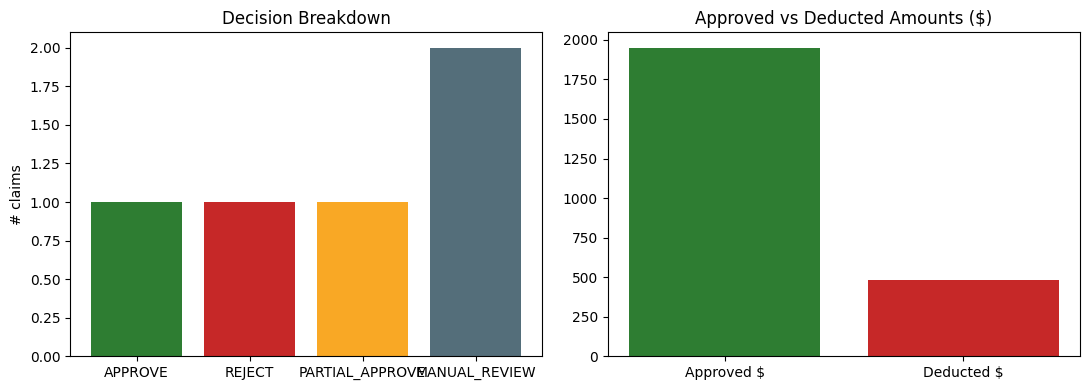

Total approved: $1950.00   Total deducted: $480.00


In [8]:
import matplotlib.pyplot as plt

decision_counts = Counter(r["decision"] for r in results)
approved_total = sum(r["approved_amount"] or 0 for r in results)
deducted_total = sum(r["deducted_amount"] or 0 for r in results)

color_map = {"APPROVE": "#2e7d32", "PARTIAL_APPROVE": "#f9a825", "REJECT": "#c62828", "MANUAL_REVIEW": "#546e7a"}
labels = list(decision_counts.keys())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(labels, [decision_counts[l] for l in labels], color=[color_map[l] for l in labels])
axes[0].set_title("Decision Breakdown"); axes[0].set_ylabel("# claims")

axes[1].bar(["Approved $", "Deducted $"], [approved_total, deducted_total], color=["#2e7d32", "#c62828"])
axes[1].set_title("Approved vs Deducted Amounts ($)")

plt.tight_layout()
plt.savefig("UI SS_1.png", dpi=150)
plt.show()

print(f"Total approved: ${approved_total:.2f}   Total deducted: ${deducted_total:.2f}")


## Sample Outputs (3 example claims, decisions + explanations)


In [9]:
for cid in ["CLM-001", "CLM-003", "CLM-004"]:
    r = next(x for x in results if x["claim_id"] == cid)
    print(f"--- {cid} ---")
    print(f"Decision:   {r['decision']}")
    print(f"Approved:   {r['approved_amount']}")
    print(f"Deducted:   {r['deducted_amount']}")
    print(f"Missing:    {r['missing_docs']}")
    print(f"Policy refs:{r['policy_refs']}")
    print(f"Confidence: {r['confidence']}")
    print(f"Explanation:{r['explanation']}")
    print()


--- CLM-001 ---
Decision:   APPROVE
Approved:   1110.0
Deducted:   0.0
Missing:    []
Policy refs:['POL-APR-02']
Confidence: 0.9
Explanation:All items are eligible, receipts are complete, amounts are within per-diem caps, and the total is within the agent's approval authority.

--- CLM-003 ---
Decision:   PARTIAL_APPROVE
Approved:   840.0
Deducted:   100.0
Missing:    []
Policy refs:['POL-APR-02', 'POL-PD-02']
Confidence: 0.85
Explanation:Eligible items within policy are approved; $100.0 deducted for amounts exceeding per-diem caps.

--- CLM-004 ---
Decision:   MANUAL_REVIEW
Approved:   None
Deducted:   None
Missing:    ['lodging: Hotel, 3 nights']
Policy refs:['POL-AIR-01', 'POL-APR-03', 'POL-RCT-01', 'POL-RCT-02']
Confidence: 0.6
Explanation:Routed to Manual Review: missing required receipt(s); business/first-class airfare policy exception; total exceeds agent's auto-approval authority. Amount pending reviewer determination.



## Design Notes & Reasoning

**Assumptions**
- Appendix B item fields (`fare_class`, `nights`, `days`, `receipt_attached`) are inferred
  directly from the descriptions/table in the PDF (e.g. "2 nights @ $180" -> `nights: 2`).
- "Total" for approval-threshold purposes is the *reimbursable* total (after per-diem caps,
  excluding ineligible items) per the policy's own note under POL-APR-*.
- A missing receipt or a business-class fare always routes to Manual Review even if the claim
  would otherwise also require a per-diem deduction -- the amount is left undetermined
  (`null`) rather than guessed, since only a reviewer can resolve the exception.

**Trade-offs**
- The deterministic fallback agent duplicates some of the LLM's "reasoning" as plain Python
  control flow. This was a deliberate trade-off: it keeps the notebook 100% runnable without
  API keys/network access (matching the free-tier/local-tools constraint) while still letting
  a live LLM take over tool selection and explanation-writing when a key is available.
- `duplicate_detector` is intentionally naive (same employee + trip_start + total) rather than
  fuzzy-matching -- sufficient for this 5-claim sample, would need a real matching strategy
  (e.g. embedding similarity on description + date window) at scale.
- Explanations from the deterministic path are templated, not free-form LLM prose. This is a
  readability/latency trade-off; the live-LLM path produces more natural explanations.

**Why certain claims are routed to Manual Review**
- **CLM-004**: business-class airfare (POL-AIR-01 exception), a missing lodging receipt
  (POL-RCT-02), *and* a reimbursable total that would exceed the $2,000 director tier
  (POL-APR-03) -- three independent triggers, each individually sufficient.
- **CLM-005**: the $220 client-dinner meal has no attached receipt, and any item over $25
  requires one (POL-RCT-01/02) -- routed to Manual Review rather than rejected, since the
  expense itself looks legitimate and may simply need the receipt requested.

**What I'd improve next**
- Replace the naive duplicate detector with a proper similarity/embedding-based check.
- Add a retrieval step (e.g. simple vector store) over the policy text instead of a hand-coded
  dict, so the same pipeline generalizes to a longer, evolving policy document.
- Add unit tests / an eval script asserting the expected decision for each sample claim (listed
  as an optional enhancement) to guard against regressions when the policy or tools change.
- Persist an audit trail (tool calls + intermediate values) per claim for reviewer transparency,
  not just the final `tools_used` list.


## Assumptions and Limitations
- Uses only the 5 provided sample claims and the mock policy in Appendix A; no real employee
  or company data.
- The live-LLM path requires `anthropic` + `ANTHROPIC_API_KEY`; it is optional, not required to
  run or grade this notebook.
- Per-diem caps for `ground_transport` are supported by the tool but unused by the 5 sample
  claims (none include that category).
- Amounts for `MANUAL_REVIEW` decisions are left as `null` by design -- see Design Notes.
- This is a lightweight prototype, not a production system: no persistence, auth, or
  concurrent-claim handling.


## Final Structured Output


In [10]:
print(json.dumps(results, indent=2))


[
  {
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-APR-02"
    ],
    "confidence": 0.9,
    "explanation": "All items are eligible, receipts are complete, amounts are within per-diem caps, and the total is within the agent's approval authority.",
    "tools_used": [
      "policy_lookup",
      "receipt_completeness_check",
      "per_diem_limit_checker",
      "timeliness_check",
      "duplicate_detector",
      "approval_threshold_check"
    ],
    "claim_id": "CLM-001"
  },
  {
    "decision": "REJECT",
    "approved_amount": 0.0,
    "deducted_amount": 380.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-02"
    ],
    "confidence": 0.95,
    "explanation": "All claimed items are on the ineligible list (e.g. spa/minibar/personal) and are rejected in full.",
    "tools_used": [
      "policy_lookup",
      "receipt_completeness_check",
      "per_diem_limit_checker",
    